# Strategy and Recommendations - Module 5.1

Translates the Project 4 visibility and efficiency rankings into decisions NY Racing can act
on: individual sponsor recommendation briefs, a three-scenario strategic comparison, and clear
decision guidance with risk assessment.

**Sponsors:** FedEx, NAPA Auto Parts, McDonald's, Love's Travel Stops. **Author:** Aylin Yasgul.

Inputs: `outputs/project4/rankings.csv`, `outputs/project4/scored_dataset.csv`.
Outputs: `outputs/project5/` (evaluation matrix, recommendation briefs, scenario comparison).


## 1. Setup and Load Rankings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

P4 = '../outputs/project4'
OUT = '../outputs/project5'
os.makedirs(OUT, exist_ok=True)

rankings = pd.read_csv(f'{P4}/rankings.csv')
scored = pd.read_csv(f'{P4}/scored_dataset.csv')

print('Final Rankings Summary:')
print('=' * 70)
print(rankings[['sponsor','total_visibility','visibility_rank','efficiency','efficiency_rank','cost_mid']].to_string(index=False))

Final Rankings Summary:
            sponsor  total_visibility  visibility_rank  efficiency  efficiency_rank  cost_mid
    NAPA Auto Parts           1218.75                1   56.686047                4      21.5
              FedEx           1215.42                2   65.698378                2      18.5
         McDonald's            913.57                3   65.255000                3      14.0
Love's Travel Stops            698.79                4   82.210588                1       8.5


## 2. Multi-Criteria Evaluation Matrix

Rank alone hides trade-offs. We convert each rank to a 0-100 score (rank 1 = 100) and combine
visibility and efficiency into a single recommendation score. A balanced 40/40 split is used,
with a 20% consistency component (lower weekly volatility = more reliable).

In [2]:
def normalize_rank(ranks, n):
    return (n - ranks + 1) / n * 100

# consistency: lower weekly std = higher score
wk = scored.groupby('sponsor')['visibility_score'].std().rename('week_std')
n = len(rankings)
eval_matrix = rankings.merge(wk, on='sponsor')
eval_matrix['vis_score'] = normalize_rank(eval_matrix['visibility_rank'], n)
eval_matrix['eff_score'] = normalize_rank(eval_matrix['efficiency_rank'], n)
# invert std to a 0-100 consistency score
s = eval_matrix['week_std']
eval_matrix['consistency_score'] = ((s.max() - s) / (s.max() - s.min()) * 100).round(1)
eval_matrix['rec_score'] = (eval_matrix['vis_score']*0.4 + eval_matrix['eff_score']*0.4
                            + eval_matrix['consistency_score']*0.2).round(1)
eval_matrix = eval_matrix.sort_values('rec_score', ascending=False)
eval_matrix.to_csv(f'{OUT}/evaluation_matrix.csv', index=False)
print('MULTI-CRITERIA EVALUATION (rec_score = 0.4 vis + 0.4 eff + 0.2 consistency)')
print('=' * 70)
print(eval_matrix[['sponsor','vis_score','eff_score','consistency_score','rec_score']].to_string(index=False))

MULTI-CRITERIA EVALUATION (rec_score = 0.4 vis + 0.4 eff + 0.2 consistency)
            sponsor  vis_score  eff_score  consistency_score  rec_score
Love's Travel Stops       25.0      100.0              100.0       70.0
    NAPA Auto Parts      100.0       25.0               92.6       68.5
              FedEx       75.0       75.0                0.0       60.0
         McDonald's       50.0       50.0               52.6       50.5


## 3. Top Candidates: Efficiency vs. Visibility, and the Overlap

In [3]:
top_eff = rankings.nsmallest(3, 'efficiency_rank')['sponsor'].tolist()
top_vis = rankings.nsmallest(3, 'visibility_rank')['sponsor'].tolist()
overlap = [s for s in top_vis if s in top_eff]
vis_only = [s for s in top_vis if s not in top_eff]
eff_only = [s for s in top_eff if s not in top_vis]
print('Top 3 by visibility :', top_vis)
print('Top 3 by efficiency :', top_eff)
print()
print('Overlap (best bets)        :', overlap)
print('Visibility-only (premium)  :', vis_only)
print('Efficiency-only (value)    :', eff_only)

Top 3 by visibility : ['NAPA Auto Parts', 'FedEx', "McDonald's"]
Top 3 by efficiency : ["Love's Travel Stops", 'FedEx', "McDonald's"]

Overlap (best bets)        : ['FedEx', "McDonald's"]
Visibility-only (premium)  : ['NAPA Auto Parts']
Efficiency-only (value)    : ["Love's Travel Stops"]


> **Interpretation.** FedEx and McDonald's appear on both lists (consistent value). NAPA is
> visibility-only (premium play: highest exposure, highest cost). Love's is efficiency-only (value
> play: best points per dollar, lowest exposure). This split is the basis for the three strategies.

## 4. Sponsor Profiles

Compile every relevant metric for the sponsors we will recommend, so the briefs are built on
organized evidence rather than lookups mid-writing.

In [4]:
def compile_profile(sponsor):
    r = rankings[rankings['sponsor'] == sponsor].iloc[0]
    sd = scored[scored['sponsor'] == sponsor]
    return {
        'sponsor': sponsor,
        'visibility_rank': int(r['visibility_rank']),
        'efficiency_rank': int(r['efficiency_rank']),
        'total_visibility': float(r['total_visibility']),
        'efficiency': float(r['efficiency']),
        'cost_mid': float(r['cost_mid']),
        'races': int(len(sd)),
        'avg_week': float(sd['visibility_score'].mean()),
        'best_week': float(sd['visibility_score'].max()),
        'worst_week': float(sd['visibility_score'].min()),
        'consistency': float(sd['visibility_score'].std()),
        'wins': int(sd['is_win'].sum()),
        'top_5': int((sd['finish_position'] <= 5).sum()),
        'top_10': int((sd['finish_position'] <= 10).sum()),
    }

# dataset averages for comparison
avg = {
    'total_visibility': rankings['total_visibility'].mean(),
    'efficiency': rankings['efficiency'].mean(),
    'wins': scored.groupby('sponsor')['is_win'].sum().mean(),
    'top_5': scored.groupby('sponsor').apply(lambda x: (x['finish_position']<=5).sum()).mean(),
    'top_10': scored.groupby('sponsor').apply(lambda x: (x['finish_position']<=10).sum()).mean(),
}
profiles = {s: compile_profile(s) for s in ['FedEx', "Love's Travel Stops", 'NAPA Auto Parts']}
for s, p in profiles.items():
    print(f"{s}: vis#{p['visibility_rank']} eff#{p['efficiency_rank']} total {p['total_visibility']:.0f} "
          f"eff {p['efficiency']:.1f} cost ${p['cost_mid']:.1f}M wins {p['wins']} top5 {p['top_5']}")

FedEx: vis#2 eff#2 total 1215 eff 65.7 cost $18.5M wins 3 top5 12
Love's Travel Stops: vis#4 eff#1 total 699 eff 82.2 cost $8.5M wins 0 top5 2
NAPA Auto Parts: vis#1 eff#4 total 1219 eff 56.7 cost $21.5M wins 1 top5 11


## 5. Recommendation Briefs

Each brief follows a five-question framework: what stands out, what data supports it, what risks
exist, how it connects to NY Racing, and what research would strengthen the case.

In [5]:
def pct_vs(value, base):
    return (value / base - 1) * 100

NARRATIVE = {
    'FedEx': {
        'type': 'Primary (Balanced)',
        'summary': ("FedEx is the balanced best bet: it ranks #2 in both visibility and efficiency, "
                    "the best combined position of any sponsor. It delivers near-maximum exposure without "
                    "the premium price of the top-visibility option."),
        'strengths': [
            ("Strong on both dimensions", "Ranks #2 in visibility (1,215 points) AND #2 in efficiency "
             "(65.7 pts/$M). No other sponsor is top-2 on both, so FedEx minimizes the trade-off."),
            ("Best on-track performance", "Led the field with 3 wins and 12 top-5 finishes, the most wins "
             "of any tracked sponsor. On-track success drives the visibility that sponsors pay for."),
            ("Near-max exposure at a lower price", "FedEx delivers 99.7% of the top sponsor's visibility "
             "at roughly 14% lower cost ($18.5M vs $21.5M), a materially better value for almost the same reach."),
        ],
        'risks': [
            ("Higher weekly volatility", "Medium", "FedEx has the highest week-to-week variance (std 11.6), "
             "driven by boom-or-bust superspeedway results.", "Frame expectations around season totals, not single races."),
            ("Premium-tier cost", "Medium", "At an estimated $18.5M it is still a top-tier investment that "
             "may strain a constrained budget.", "Use the efficiency story to justify the spend, or consider the value alternative."),
        ],
        'connection': ("FedEx fits a growth-with-discipline posture: it maximizes exposure while keeping a "
                       "defensible ROI story, which serves both a CMO (reach) and a CFO (value)."),
        'conclusion': "the strongest all-around option, recommended as the primary choice for NY Racing.",
    },
    "Love's Travel Stops": {
        'type': 'Alternative (Value)',
        'summary': ("Love's is the value play: it ranks #1 in efficiency (82.2 pts/$M) at the lowest cost "
                    "($8.5M). It sacrifices total exposure but delivers the most visibility per dollar and the "
                    "lowest downside risk."),
        'strengths': [
            ("Best value per dollar", "82.2 visibility points per $M, about 22% above the dataset average and "
             "the highest of any sponsor, at the lowest estimated cost."),
            ("Lowest barrier to entry", "At an estimated $8.5M it is less than half the cost of the premium "
             "options, lowering the downside if the partnership underperforms."),
            ("Consistent for its tier", "Low weekly volatility (std 8.8) means steady, predictable exposure "
             "rather than boom-or-bust."),
        ],
        'risks': [
            ("Low absolute visibility", "High", "At 699 total points (rank #4) it delivers far less raw "
             "exposure than the leaders, which may underwhelm a board expecting scale.",
             "Position as an efficient entry point, not a headline play."),
            ("Smaller-team dependency", "Medium", "Front Row Motorsports runs mid-pack; a weak season would "
             "further reduce exposure.", "Revisit if the team's competitiveness declines."),
        ],
        'connection': ("Love's fits a budget-conscious, ROI-first posture: it lets NY Racing enter with a "
                       "defensible value story and prove the model before scaling up."),
        'conclusion': "the best value alternative, recommended when budget or ROI justification is the priority.",
    },
    'NAPA Auto Parts': {
        'type': 'Alternative (Premium)',
        'summary': ("NAPA is the premium play: it ranks #1 in total visibility (1,219 points) but #4 in "
                    "efficiency, reflecting the premium price of an elite Hendrick partnership. It maximizes "
                    "exposure at the highest cost."),
        'strengths': [
            ("Maximum total exposure", "Highest total visibility (1,219 points) and the most top-10 finishes "
             "(19), the best raw reach of any sponsor."),
            ("Most consistent leader", "Lowest weekly volatility among the high-visibility sponsors (std 9.0), "
             "so the exposure is steady, not luck-driven."),
            ("Elite brand association", "Partners the sport's most popular driver on an elite team, which "
             "carries prestige value beyond the raw score."),
        ],
        'risks': [
            ("Lowest efficiency", "High", "At 56.7 pts/$M (rank #4) NAPA pays a clear premium; a CFO will "
             "question the value per dollar.", "Only pursue if maximum brand awareness outweighs ROI."),
            ("Highest cost commitment", "High", "At an estimated $21.5M it is the largest investment and the "
             "biggest downside if the partnership underperforms.", "Ensure budget flexibility before committing."),
        ],
        'connection': ("NAPA fits an aggressive brand-awareness posture: it buys the most exposure and elite "
                       "association, appropriate when growth and prestige outweigh ROI discipline."),
        'conclusion': "the premium alternative, recommended only when maximum exposure is the goal and budget allows.",
    },
}

def build_brief(sponsor, p, nar):
    L = []
    L.append(f"# Sponsor Recommendation: {sponsor}")
    L.append("")
    L.append(f"**Recommendation Type:** {nar['type']}  **Analysis Date:** {pd.Timestamp.now().strftime('%Y-%m-%d')}")
    L.append("")
    L.append("## Executive Summary")
    L.append("")
    L.append(nar['summary'])
    L.append("")
    L.append("## Key Metrics")
    L.append("")
    L.append("| Metric | Value | Context |")
    L.append("|---|---|---|")
    L.append(f"| Visibility Rank | #{p['visibility_rank']} of {len(rankings)} | {'above' if p['total_visibility']>avg['total_visibility'] else 'below'} average exposure |")
    L.append(f"| Efficiency Rank | #{p['efficiency_rank']} of {len(rankings)} | {'above' if p['efficiency']>avg['efficiency'] else 'below'} average value |")
    L.append(f"| Total Visibility | {p['total_visibility']:.0f} points | {pct_vs(p['total_visibility'], avg['total_visibility']):+.0f}% vs average |")
    L.append(f"| Efficiency | {p['efficiency']:.1f} pts/$M | {pct_vs(p['efficiency'], avg['efficiency']):+.0f}% vs average |")
    L.append(f"| Estimated Cost | ${p['cost_mid']:.1f}M/year | benchmark estimate |")
    L.append("")
    L.append("## Why This Sponsor")
    L.append("")
    for i, (title, text) in enumerate(nar['strengths'], 1):
        L.append(f"**Strength {i}: {title}.** {text}")
        L.append("")
    L.append("## Supporting Data")
    L.append("")
    L.append("| Category | " + sponsor + " | Dataset Average |")
    L.append("|---|---|---|")
    L.append(f"| Total Visibility | {p['total_visibility']:.0f} | {avg['total_visibility']:.0f} |")
    L.append(f"| Efficiency (pts/$M) | {p['efficiency']:.1f} | {avg['efficiency']:.1f} |")
    L.append(f"| Wins | {p['wins']} | {avg['wins']:.1f} |")
    L.append(f"| Top-5 Finishes | {p['top_5']} | {avg['top_5']:.1f} |")
    L.append(f"| Top-10 Finishes | {p['top_10']} | {avg['top_10']:.1f} |")
    L.append("")
    L.append(f"**Consistency:** best week {p['best_week']:.1f}, worst week {p['worst_week']:.1f}, "
             f"weekly std {p['consistency']:.1f} across {p['races']} races.")
    L.append("")
    L.append("## Risk Assessment")
    L.append("")
    for i, (title, likelihood, whatgoes, mitig) in enumerate(nar['risks'], 1):
        L.append(f"**Risk {i}: {title}** (likelihood: {likelihood})")
        L.append(f"- What could go wrong: {whatgoes}")
        L.append(f"- Mitigation: {mitig}")
        L.append("")
    L.append(f"**Cost estimate uncertainty:** the ${p['cost_mid']:.1f}M figure is a benchmark estimate. "
             "If actual cost is lower, efficiency improves; if higher, efficiency declines. Confirm with "
             "direct negotiation before finalizing.")
    L.append("")
    L.append("## Connection to NY Racing")
    L.append("")
    L.append(nar['connection'])
    L.append("")
    L.append("## Additional Research Recommended")
    L.append("")
    L.append("1. Confirm the actual deal cost and contract expiry (opportunity to negotiate).")
    L.append("2. Assess brand alignment with NY Racing's target audience.")
    L.append("3. Review the team's outlook for next season (future trajectory vs 2024 results).")
    L.append("")
    L.append("## Conclusion")
    L.append("")
    L.append(f"{sponsor} represents {nar['conclusion']}")
    L.append("")
    L.append("*Based on 2024 season data. See the methodology document for assumptions and limitations.*")
    return "\n".join(L)

fname = {'FedEx': 'recommendation_fedex.md', "Love's Travel Stops": 'recommendation_loves.md',
         'NAPA Auto Parts': 'recommendation_napa.md'}
for s, p in profiles.items():
    brief = build_brief(s, p, NARRATIVE[s])
    with open(f"{OUT}/{fname[s]}", 'w') as f:
        f.write(brief)
    print(f"Saved {fname[s]} ({NARRATIVE[s]['type']})")

Saved recommendation_fedex.md (Primary (Balanced))
Saved recommendation_loves.md (Alternative (Value))
Saved recommendation_napa.md (Alternative (Premium))


## 6. Scenario Analysis: Three Strategic Options

Sarah's ask: the sponsor is choosing between strategies, not just partners. We define three
distinct archetypes and identify the best sponsor for each.

In [6]:
SCENARIOS = {
    'maximize_visibility': {'name': 'Scenario A: Maximize Visibility',
        'objective': 'Achieve the highest possible brand exposure',
        'priority': 'Total visibility regardless of cost', 'trade_off': 'Accepts lower efficiency for maximum exposure'},
    'maximize_efficiency': {'name': 'Scenario B: Maximize Efficiency',
        'objective': 'Achieve the best return on sponsorship investment',
        'priority': 'Visibility per dollar spent', 'trade_off': 'Accepts lower total visibility for better value'},
    'balanced': {'name': 'Scenario C: Balanced Approach',
        'objective': 'Strong performance on both dimensions',
        'priority': 'Best combined visibility + efficiency rank', 'trade_off': 'May not be #1 on either metric'},
}

def identify_scenario_sponsors(r):
    res = {}
    a = r.loc[r['visibility_rank'].idxmin()]
    res['maximize_visibility'] = a
    b = r.loc[r['efficiency_rank'].idxmin()]
    res['maximize_efficiency'] = b
    r = r.copy(); r['combined_rank'] = r['visibility_rank'] + r['efficiency_rank']
    c = r.loc[r['combined_rank'].idxmin()]
    res['balanced'] = c
    return res

sc = identify_scenario_sponsors(rankings)
print('BEST SPONSOR BY SCENARIO')
print('=' * 70)
for k, row in sc.items():
    print(f"{SCENARIOS[k]['name']}: {row['sponsor']} "
          f"(vis {row['total_visibility']:.0f} rank #{int(row['visibility_rank'])}, "
          f"eff {row['efficiency']:.1f} rank #{int(row['efficiency_rank'])}, cost ${row['cost_mid']:.1f}M)")

BEST SPONSOR BY SCENARIO
Scenario A: Maximize Visibility: NAPA Auto Parts (vis 1219 rank #1, eff 56.7 rank #4, cost $21.5M)
Scenario B: Maximize Efficiency: Love's Travel Stops (vis 699 rank #4, eff 82.2 rank #1, cost $8.5M)
Scenario C: Balanced Approach: FedEx (vis 1215 rank #2, eff 65.7 rank #2, cost $18.5M)


## 7. Scenario Trade-offs

In [7]:
rows = []
for k, row in sc.items():
    rows.append({'Scenario': SCENARIOS[k]['name'].replace('Scenario ', '').split(':')[1].strip(),
                 'Sponsor': row['sponsor'], 'Visibility': row['total_visibility'],
                 'Vis_Rank': int(row['visibility_rank']), 'Efficiency': round(row['efficiency'],1),
                 'Eff_Rank': int(row['efficiency_rank']), 'Cost_$M': row['cost_mid']})
tradeoff = pd.DataFrame(rows)
max_vis, max_eff = tradeoff['Visibility'].max(), tradeoff['Efficiency'].max()
tradeoff['Vis_vs_Max_%'] = (tradeoff['Visibility'] / max_vis * 100).round(1)
tradeoff['Eff_vs_Max_%'] = (tradeoff['Efficiency'] / max_eff * 100).round(1)
print('SCENARIO TRADE-OFF COMPARISON')
print('=' * 70)
print(tradeoff.to_string(index=False))

SCENARIO TRADE-OFF COMPARISON
           Scenario             Sponsor  Visibility  Vis_Rank  Efficiency  Eff_Rank  Cost_$M  Vis_vs_Max_%  Eff_vs_Max_%
Maximize Visibility     NAPA Auto Parts     1218.75         1        56.7         4     21.5         100.0          69.0
Maximize Efficiency Love's Travel Stops      698.79         4        82.2         1      8.5          57.3         100.0
  Balanced Approach               FedEx     1215.42         2        65.7         2     18.5          99.7          79.9


## 8. Scenario Comparison Visualization

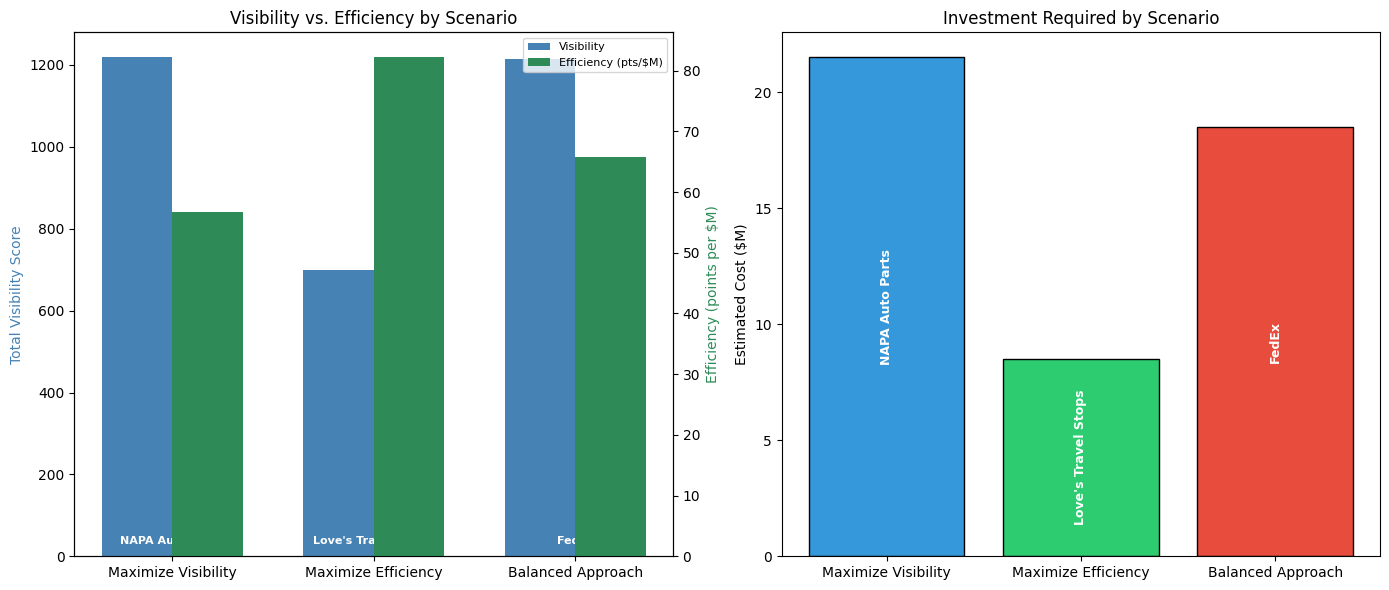

Saved scenario_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
labels = tradeoff['Scenario'].tolist()
colors = ['#3498db', '#2ecc71', '#e74c3c']  # A, B, C

ax1 = axes[0]
x = np.arange(len(labels)); w = 0.35
b1 = ax1.bar(x - w/2, tradeoff['Visibility'], w, label='Visibility', color='steelblue')
ax1.set_ylabel('Total Visibility Score', color='steelblue')
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1t = ax1.twinx()
b2 = ax1t.bar(x + w/2, tradeoff['Efficiency'], w, label='Efficiency (pts/$M)', color='seagreen')
ax1t.set_ylabel('Efficiency (points per $M)', color='seagreen')
ax1.set_title('Visibility vs. Efficiency by Scenario')
for i, s in enumerate(tradeoff['Sponsor']):
    ax1.text(x[i], 30, s, ha='center', fontsize=8, rotation=0, color='white', fontweight='bold')
l1, la1 = ax1.get_legend_handles_labels(); l2, la2 = ax1t.get_legend_handles_labels()
ax1.legend(l1 + l2, la1 + la2, loc='upper right', fontsize=8)

ax2 = axes[1]
bars = ax2.bar(labels, tradeoff['Cost_$M'], color=colors, edgecolor='black')
for bar, s in zip(bars, tradeoff['Sponsor']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, s, ha='center', va='center',
             rotation=90, fontsize=9, fontweight='bold', color='white')
ax2.set_ylabel('Estimated Cost ($M)')
ax2.set_title('Investment Required by Scenario')
plt.tight_layout()
plt.savefig(f'{OUT}/scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved scenario_comparison.png')

## 9. Scenario Comparison Document (deliverable)

In [9]:
def calculate_key_insight(sc):
    vis_sp = sc['maximize_visibility']['sponsor']
    eff_sp = sc['maximize_efficiency']['sponsor']
    bal_sp = sc['balanced']['sponsor']
    if vis_sp == eff_sp:
        return f"Notably, {vis_sp} leads BOTH visibility and efficiency, making it a clear, decisive choice."
    # how much efficiency you give up choosing max visibility, and vice versa
    vis_eff_pct = sc['maximize_visibility']['efficiency'] / sc['maximize_efficiency']['efficiency'] * 100
    eff_vis_pct = sc['maximize_efficiency']['total_visibility'] / sc['maximize_visibility']['total_visibility'] * 100
    bal_vis_pct = sc['balanced']['total_visibility'] / sc['maximize_visibility']['total_visibility'] * 100
    bal_eff_pct = sc['balanced']['efficiency'] / sc['maximize_efficiency']['efficiency'] * 100
    return (f"Choosing maximum visibility ({vis_sp}) delivers only {vis_eff_pct:.0f}% of the best "
            f"efficiency, while choosing maximum efficiency ({eff_sp}) delivers only {eff_vis_pct:.0f}% of "
            f"the best exposure. The balanced option ({bal_sp}) captures {bal_vis_pct:.1f}% of the top "
            f"exposure at {bal_eff_pct:.0f}% of the best efficiency, making it the standout compromise.")

key_insight = calculate_key_insight(sc)

L = []
L.append('# Sponsorship Strategy: Scenario Comparison')
L.append('')
L.append(f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d')}")
L.append('')
L.append('## Overview')
L.append('')
L.append('This document compares three strategic approaches to NASCAR sponsorship selection, based on '
         'our visibility scoring and ROI analysis. Each scenario optimizes for a different business priority. '
         'The goal is to present options, not a single answer, so decision-makers can choose based on their priorities.')
L.append('')
L.append('## The Three Scenarios')
L.append('')
detail = {
 'maximize_visibility': ('Teams prioritizing brand awareness and market presence',
     ['Maximum brand exposure across all channels', 'Strongest performance-driven visibility', 'Most media attention'],
     ['Higher cost commitment', 'Lower return per dollar', 'May not fit budget constraints'],
     ['You have budget flexibility', 'Brand awareness is the primary goal', 'You will pay a premium for top exposure']),
 'maximize_efficiency': ('Teams prioritizing return on investment',
     ['Best visibility per dollar spent', 'More defensible ROI story', 'Lowest total investment required'],
     ['Lower absolute visibility', 'May miss premium exposure opportunities', 'Smaller presence than the top-visibility option'],
     ['Budget is constrained', 'ROI justification is critical', 'You need to prove value before scaling up']),
 'balanced': ('Teams seeking the middle ground',
     ['Strong performance on both dimensions', 'Reasonable cost with good exposure', 'Minimizes regret on either metric'],
     ['Neither maximum exposure nor maximum efficiency', 'Compromises on both extremes'],
     ['You have moderate budget and moderate goals', 'Multiple stakeholders with different priorities', 'Risk mitigation is important']),
}
for k in ['maximize_visibility', 'maximize_efficiency', 'balanced']:
    row = sc[k]; best_for, adv, dis, when = detail[k]
    L.append(f"### {SCENARIOS[k]['name']}")
    L.append('')
    L.append(f"**Best for:** {best_for}")
    L.append('')
    L.append('| Metric | Value |')
    L.append('|---|---|')
    L.append(f"| Recommended Sponsor | {row['sponsor']} |")
    L.append(f"| Total Visibility | {row['total_visibility']:.0f} points (rank #{int(row['visibility_rank'])}) |")
    L.append(f"| Efficiency | {row['efficiency']:.1f} pts/$M (rank #{int(row['efficiency_rank'])}) |")
    L.append(f"| Estimated Investment | ${row['cost_mid']:.1f}M |")
    L.append('')
    L.append('**Advantages:** ' + '; '.join(adv) + '.')
    L.append('')
    L.append('**Disadvantages:** ' + '; '.join(dis) + '.')
    L.append('')
    L.append('**When to choose:** ' + '; '.join(when) + '.')
    L.append('')
L.append('## Trade-off Summary')
L.append('')
L.append('| Scenario | Sponsor | Visibility | Efficiency | Cost ($M) | Vis vs Max | Eff vs Max |')
L.append('|---|---|---|---|---|---|---|')
for _, t in tradeoff.iterrows():
    L.append(f"| {t['Scenario']} | {t['Sponsor']} | {t['Visibility']:.0f} | {t['Efficiency']:.1f} | "
             f"{t['Cost_$M']:.1f} | {t['Vis_vs_Max_%']:.0f}% | {t['Eff_vs_Max_%']:.0f}% |")
L.append('')
L.append('## Visual Comparison')
L.append('')
L.append('See `scenario_comparison.png` (visibility vs efficiency by scenario, and cost by scenario).')
L.append('')
L.append('## Decision Guidance')
L.append('')
L.append(f"- **If budget is NOT a constraint:** choose Scenario A (Maximize Visibility), {sc['maximize_visibility']['sponsor']}. Pay for the best exposure available.")
L.append(f"- **If budget IS a constraint:** choose Scenario B (Maximize Efficiency), {sc['maximize_efficiency']['sponsor']}. Get the most value per dollar.")
L.append(f"- **If you have mixed priorities:** choose Scenario C (Balanced), {sc['balanced']['sponsor']}. Optimize across dimensions without extremes.")
L.append('')
L.append('## Key Insight')
L.append('')
L.append(key_insight)
L.append('')
L.append('## Recommendation')
L.append('')
L.append(f"For NY Racing's current situation, we recommend the **Balanced Approach ({sc['balanced']['sponsor']})** as the primary strategy:")
L.append('')
L.append(f"1. It captures {sc['balanced']['total_visibility']/max_vis*100:.1f}% of the maximum exposure while ranking #2 in efficiency, so little is sacrificed on either front.")
L.append('2. It serves multiple stakeholders at once (reach for the CMO, value for the CFO).')
L.append(f"3. Keep {sc['maximize_efficiency']['sponsor']} as the value fallback if budget tightens, and {sc['maximize_visibility']['sponsor']} as the premium option if maximum exposure becomes the goal.")
L.append('')
L.append('*This scenario analysis is based on 2024 season data. See the methodology document for assumptions and limitations.*')

with open(f'{OUT}/scenario_comparison.md', 'w') as f:
    f.write("\n".join(L))
print('Saved scenario_comparison.md')
print()
print('KEY INSIGHT:', key_insight)

Saved scenario_comparison.md

KEY INSIGHT: Choosing maximum visibility (NAPA Auto Parts) delivers only 69% of the best efficiency, while choosing maximum efficiency (Love's Travel Stops) delivers only 57% of the best exposure. The balanced option (FedEx) captures 99.7% of the top exposure at 80% of the best efficiency, making it the standout compromise.
